In [12]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

def parse_blinded_limits(text) -> dict[str, float]:
    block = re.search(r"Asymptotic Limits for Blinded Fit(.*?)Done", text, re.DOTALL)
    if not block:
        raise RuntimeError("Could not find blinded fit block.")
    block = block.group(1)
    pattern = r"Expected\s+([0-9.]+)%:\s+r < ([\d.]+)"
    matches = re.findall(pattern, block)
    limits = {percentile: float(value) for percentile, value in matches}
    return {
        "median": limits["50.0"],
        "down1": limits["16.0"],
        "up1": limits["84.0"],
        "down2": limits["2.5"],
        "up2": limits["97.5"]
    }

def get_UL_results(fit_result_files) -> dict[str, dict[str, float]]:
    '''
    Returns: dictionary[ label = discriminant name, dict = parsed limits]
    '''
    results = {}
    for label, filepath in fit_result_files.items():
        if not filepath.exists():
            raise FileNotFoundError(f"{filepath} does not exist.")
        text = filepath.read_text()
        results[label] = parse_blinded_limits(text)
    return results

def plot_limits(results_dict, outfile):
    # Font sizes
    label_fontsize = 24
    tick_fontsize = 20
    legend_fontsize = 20
    rlabel = "13.6 TeV"

    labels = list(results_dict.keys())
    N = len(labels)
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # CONTROL BAR THICKNESS AND SPACING
    bar_height = 0.5  # ⬅️ thinner bars
    bar_spacing = 0 # ⬅️ zero spacing

    for i, label in enumerate(labels):
        vals = results_dict[label]
        median = vals["median"]
        low1 = median - vals["down1"]
        high1 = vals["up1"] - median
        low2 = median - vals["down2"]
        high2 = vals["up2"] - median

        y_center = i * (bar_height + bar_spacing)

        # ±2σ band
        ax.barh(y_center, low2 + high2, left=median - low2, height=bar_height, color="gold", zorder=1, edgecolor='none')
        # ±1σ band
        ax.barh(y_center, low1 + high1, left=median - low1, height=bar_height, color="forestgreen", zorder=2, edgecolor='none')
        # Median line
        ax.vlines(median, y_center - bar_height / 2, y_center + bar_height / 2, color="black", linestyle="--", linewidth=1.2, zorder=3)

        # Text labels
        ax.text(-0.4, y_center + 0.07, f"{label}", ha="left", fontsize=tick_fontsize, weight='bold', transform=ax.get_yaxis_transform())
        ax.text(-0.4, y_center - 0.07, f"Expected {median:.2f}", ha="left", fontsize=tick_fontsize, transform=ax.get_yaxis_transform())

    # Vertical theory line
    i_top = 0
    y_top_center = (N - 1) * (bar_height + bar_spacing)
    y_top_edge = y_top_center + bar_height / 2
    ax.vlines(x=1.0, ymin=-bar_height / 2, ymax=y_top_edge, color="red", linestyle="-", linewidth=1.5, zorder=4)
    
    # Axis styling
    ax.set_xlim(left=0)
    ax.set_xlabel(r"Upper 95% CLs limit on $\sigma(\mathrm{pp} \rightarrow \mathrm{HH}) / \sigma_\mathrm{SM}$", fontsize=label_fontsize)
    ax.tick_params(axis="x", labelsize=tick_fontsize, zorder=5)
    # Force the ticks and spines to be drawn on top
    ax.set_axisbelow(False)

    # CMS label
    hep.cms.label("Preliminary", data=False, loc=0, year='2022', com='13.6')

    # Legend
    theory_legend = [plt.Line2D([0], [0], color="red", linestyle="-", label="Theory prediction")]

    from matplotlib.patches import Rectangle
    from matplotlib.legend_handler import HandlerBase

    # Custom handler to draw a patch with a dashed line through the center
    class PatchWithLineHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
            patch_color = orig_handle[0]
            line_style = orig_handle[1]
            # Full-size patch
            patch = Rectangle([xdescent, ydescent], width, height, facecolor=patch_color, edgecolor="none", transform=trans, zorder=1)
            # Dashed line through center
            line = plt.Line2D([xdescent, xdescent + width], [ydescent + height / 2] * 2, linestyle=line_style, color="black",
                linewidth=1.5, transform=trans, zorder=2)
            return [patch, line]

    # Define legend handles as (color, linestyle)
    green_legend = ("forestgreen", "--")
    yellow_legend = ("gold", "--")

    # Legend items
    other_legend = [
        green_legend,
        yellow_legend,
        plt.Line2D([0], [0], color="black", linestyle="--", label="Median expected")
    ]

    fig.legend(handles=theory_legend, loc="upper right", bbox_to_anchor=(0.71, 0.88), fontsize=legend_fontsize, frameon=False)
    # Add legend with custom handler
    fig.legend(handles=other_legend, labels=[r"$\pm 1\sigma$ expected", r"$\pm 2\sigma$ expected", "Median expected"],
        loc="upper right", bbox_to_anchor=(0.95, 0.88), fontsize=legend_fontsize, frameon=False, handler_map={tuple: PatchWithLineHandler()})

    # Set y-axis limits precisely to avoid spacing
    total_height = N * (bar_height + bar_spacing)
    top_margin = 0.6  # try 0.5–0.8 until you're happy
    yticks = []
    for i in range(N):
        y_center = i * (bar_height + bar_spacing)
        yticks.extend([y_center - bar_height / 2, y_center + bar_height / 2])
    ax.set_yticks(yticks)
    # Remove minor ticks and customize major ticks
    ax.tick_params(axis="y", which="minor", left=False, right=False)
    ax.tick_params(axis="y", which="major", length=12, width=2, labelsize=0, left=True, right=True)
    
    ax.set_ylim(-bar_height / 2, total_height - bar_spacing - bar_height / 2 + top_margin)
    # Layout
    plt.subplots_adjust(left=0.26, right=0.97, top=0.90, bottom=0.14)
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()


In [13]:
%config InlineBackend.figure_format = 'retina'

## Project: Disc_Study_New

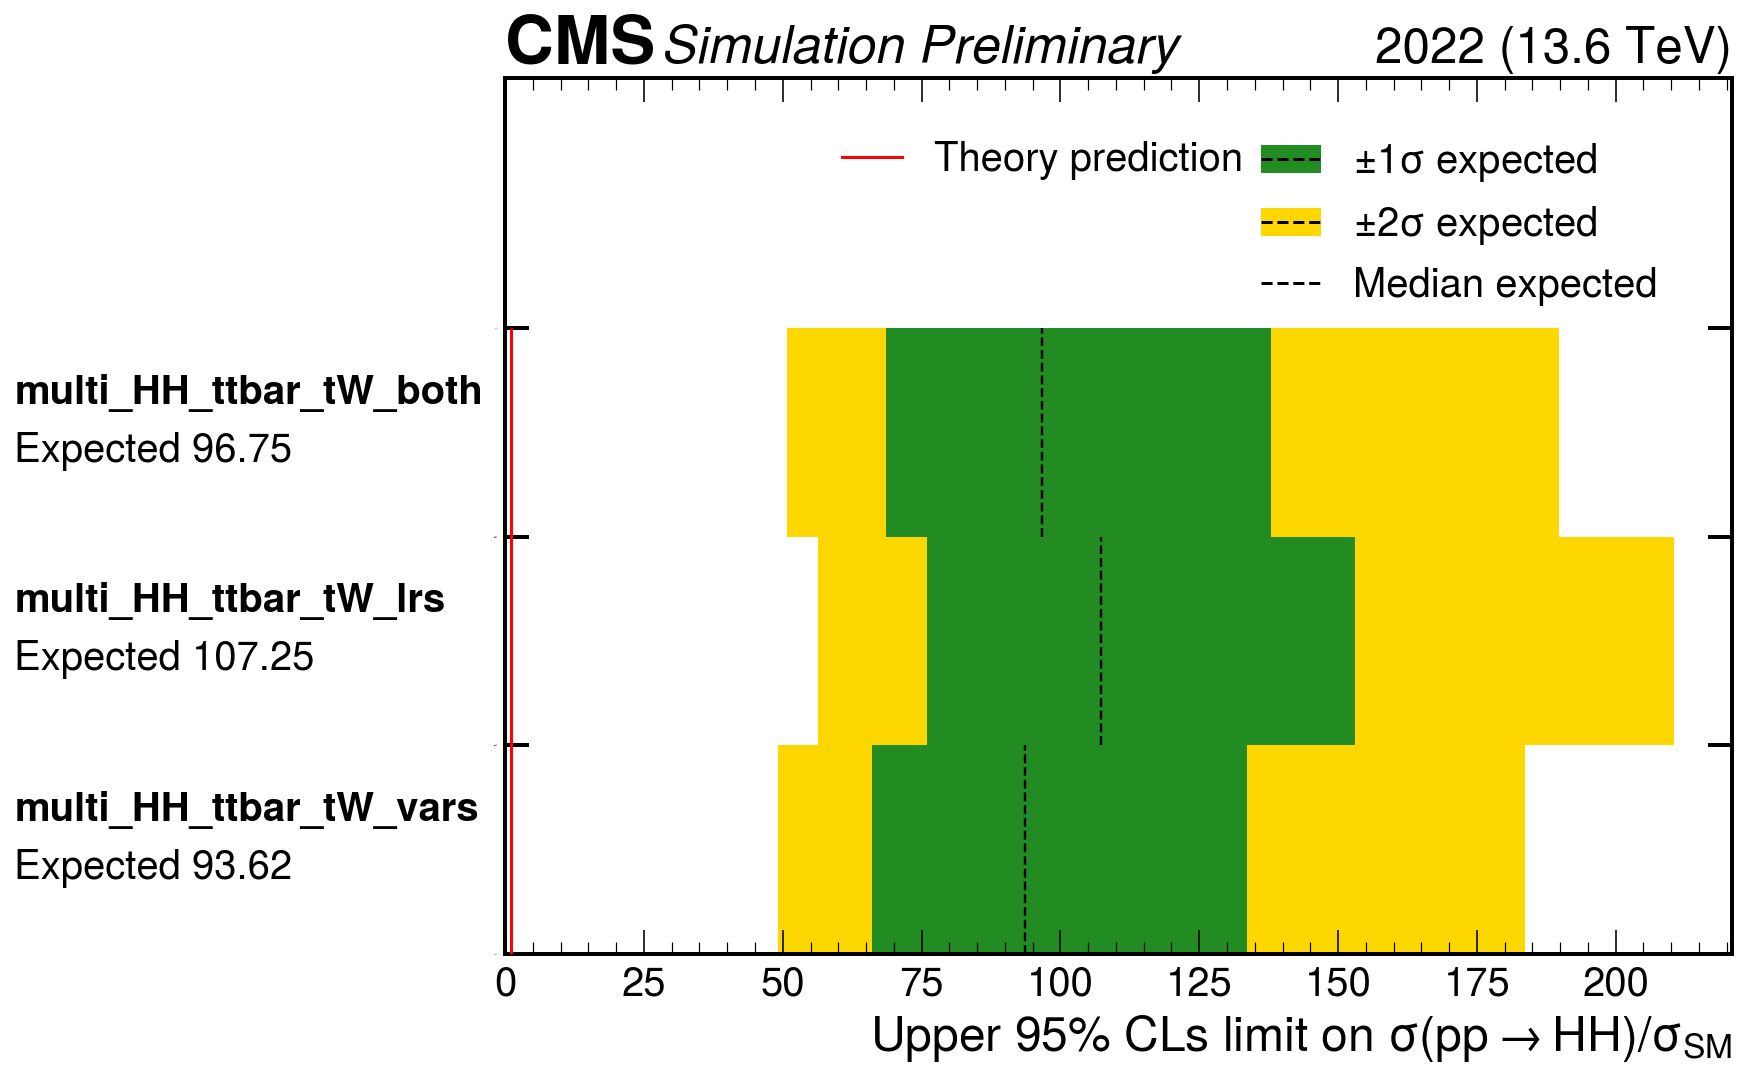

In [14]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/NNInf_even')
fit_result_files = {
    "multi_HH_ttbar_tW_vars": workdir / "fits_new" / "multi_HH_ttbar_tW_vars" / "2022" / "SL_4j_resolved" / "fit_results_combined_datacard.txt",
    "multi_HH_ttbar_tW_lrs": workdir / "fits_new" / "multi_HH_ttbar_tW_lrs" / "2022" / "SL_4j_resolved" / "fit_results_combined_datacard.txt",
    "multi_HH_ttbar_tW_both": workdir / "fits_new" / "multi_HH_ttbar_tW_both" / "2022" / "SL_4j_resolved" / "fit_results_combined_datacard.txt"
}
results = get_UL_results(fit_result_files)
plot_limits(results, outfile = workdir/"brazilian_plot.pdf")

## Project: Disc_Study_Rep

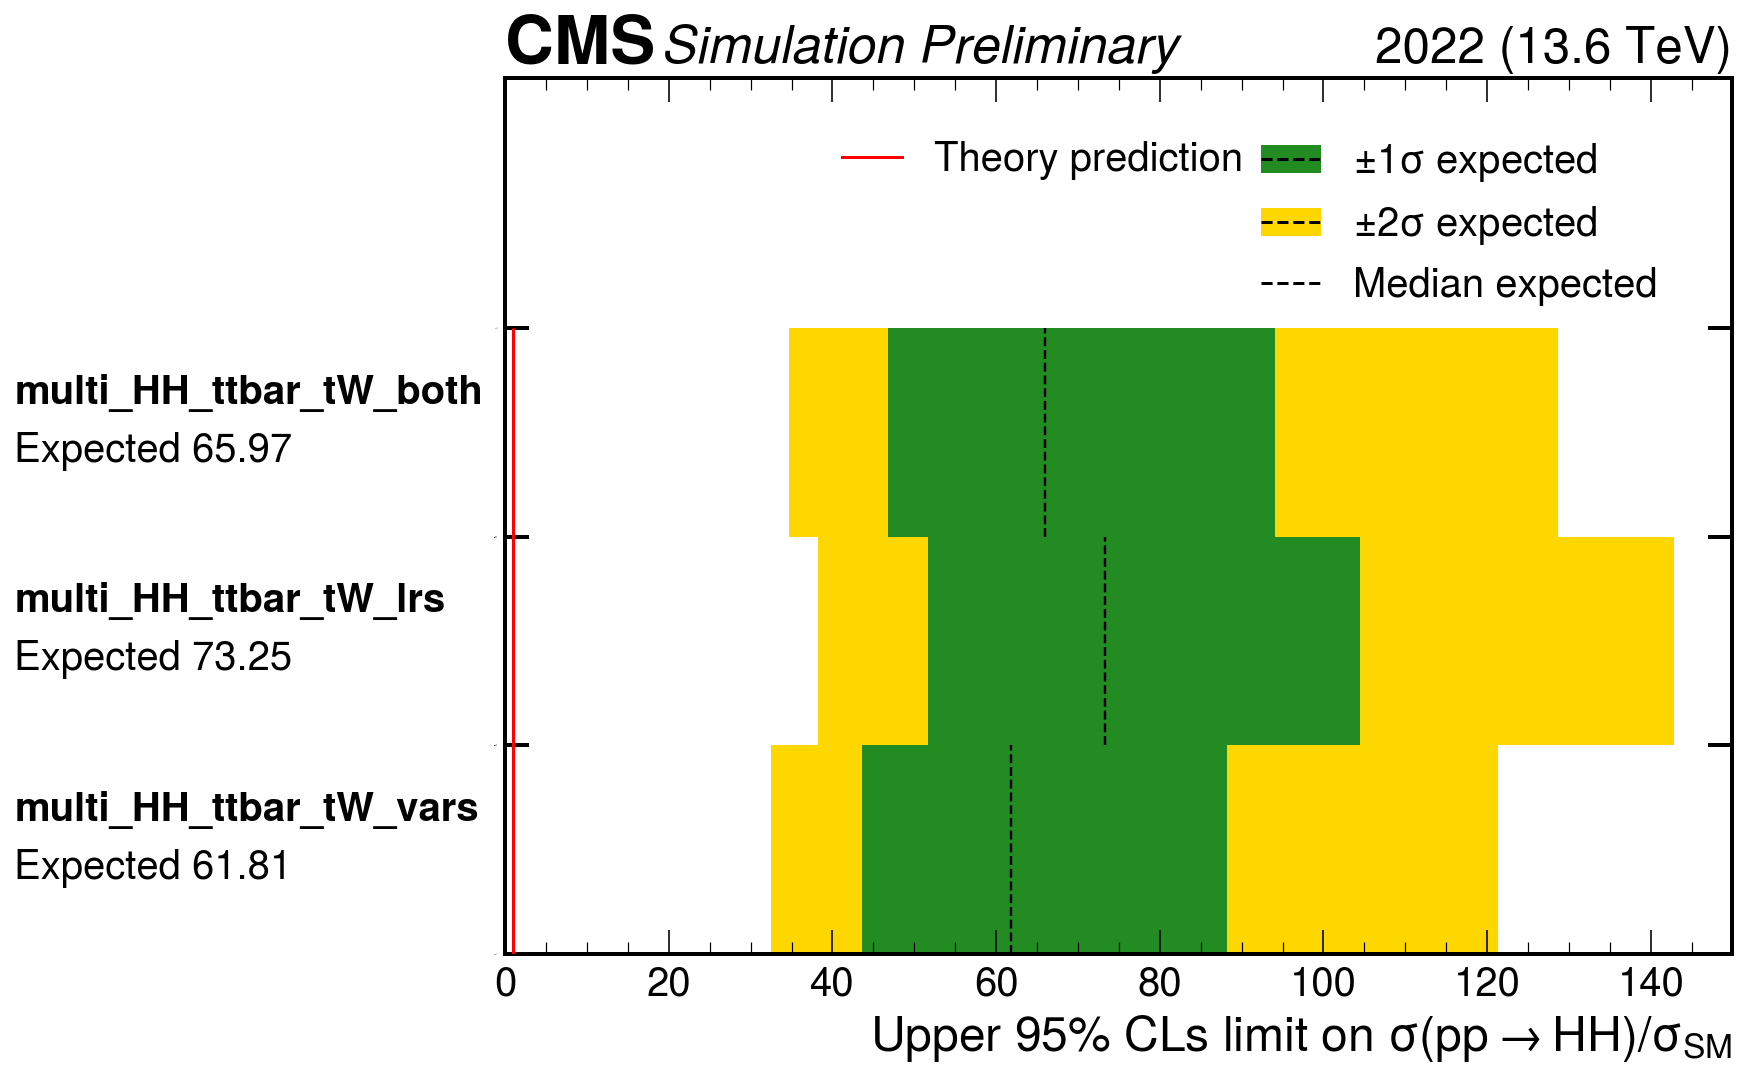

In [17]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_Rep/0806_NNInf_even')
fit_result_files = {
    "multi_HH_ttbar_tW_vars": workdir / "fits" / "multi_HH_ttbar_tW_vars" / "fit_results_multi_HH_ttbar_tW_vars.txt",
    "multi_HH_ttbar_tW_lrs": workdir / "fits" / "multi_HH_ttbar_tW_lrs" / "fit_results_multi_HH_ttbar_tW_lrs.txt",
    "multi_HH_ttbar_tW_both": workdir / "fits" / "multi_HH_ttbar_tW_both" / "fit_results_multi_HH_ttbar_tW_both.txt"
}
results = get_UL_results(fit_result_files)
plot_limits(results, outfile = workdir/"brazilian_plot.pdf")

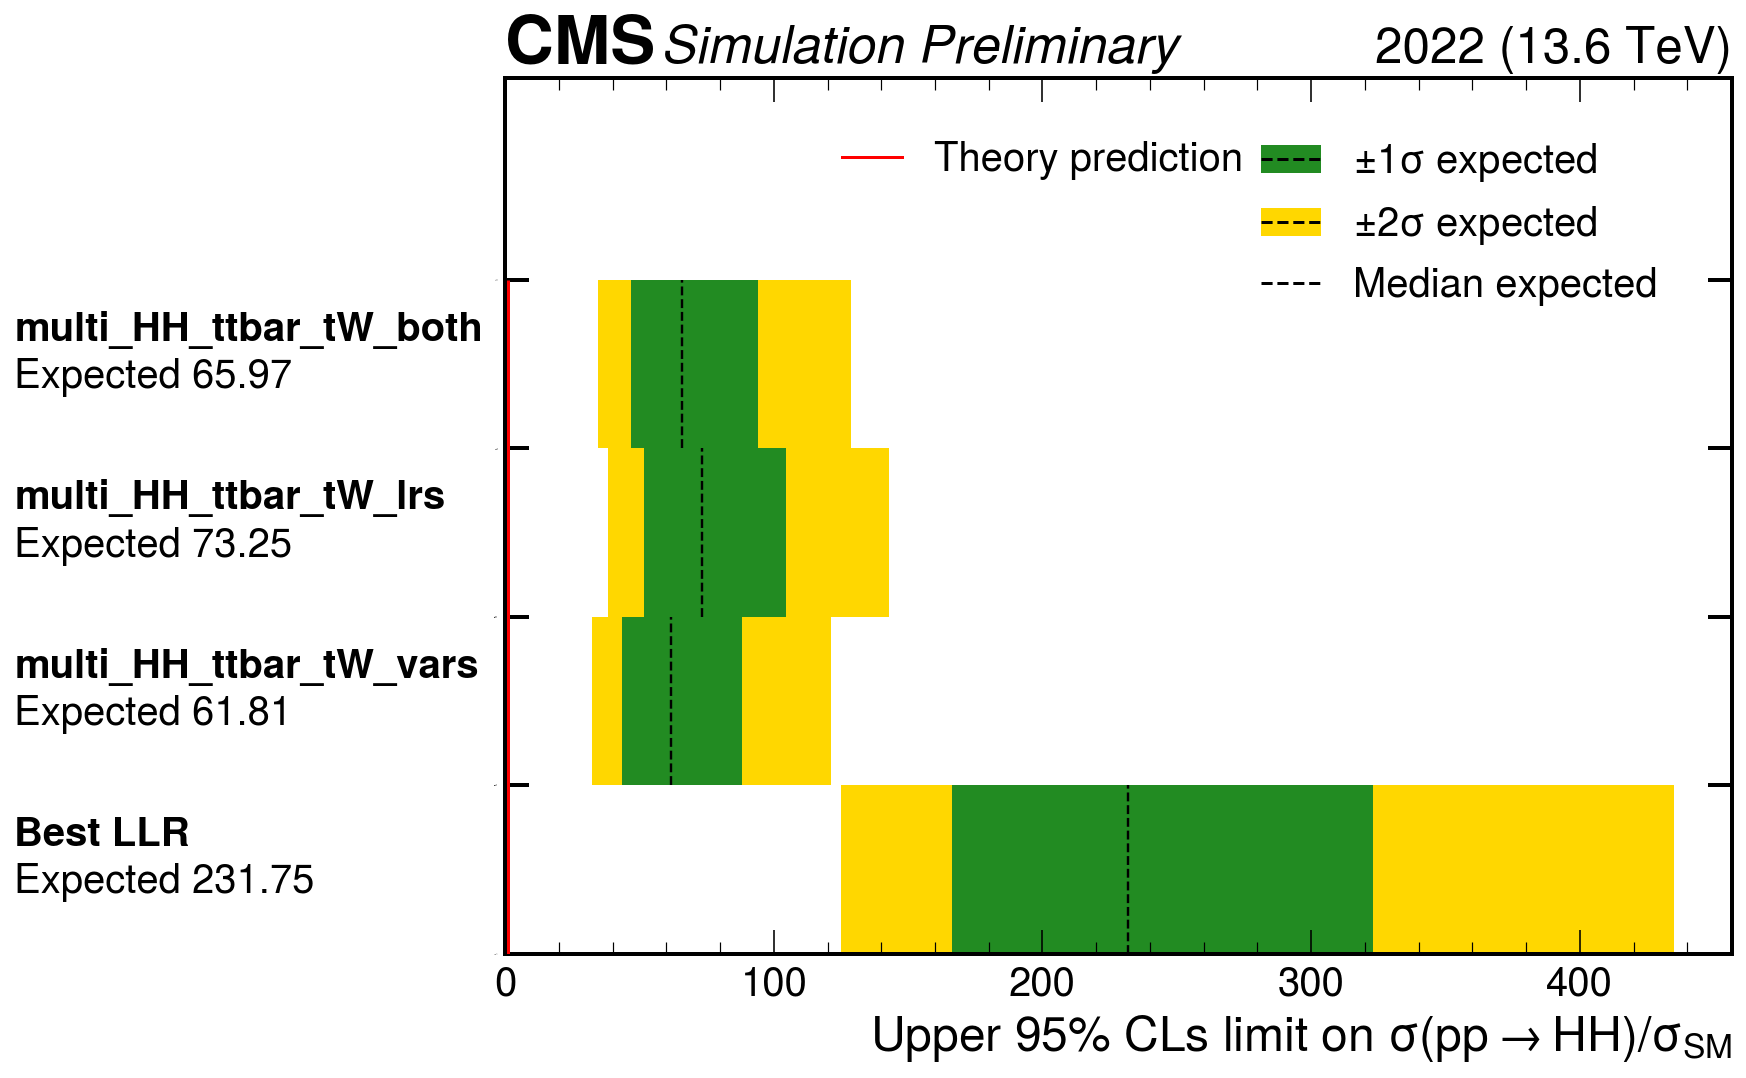

In [18]:
study_dir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_Rep')
workdir_NN = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_Rep/0806_NNInf_even')
workdir_LLR = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_Rep/0805_LLR_odd')
fit_result_files = {
    "Best LLR": workdir_LLR / "fit_results" / "SL_4j_resolved" / "bjet0_pt_x_bjets_dEta_x_bjets_dPhi_x_bjets_dR_x_bjets_mbb_x_mjj_x_trijet_pt_rat_llr" / "SL_4j_resolved_bjet0_pt_x_bjets_dEta_x_bjets_dPhi_x_bjets_dR_x_bjets_mbb_x_mjj_x_trijet_pt_rat_llr_2022_asimov_datacard_fit_results.txt",
    "multi_HH_ttbar_tW_vars": workdir_NN / "fits" / "multi_HH_ttbar_tW_vars" / "fit_results_multi_HH_ttbar_tW_vars.txt",
    "multi_HH_ttbar_tW_lrs": workdir_NN / "fits" / "multi_HH_ttbar_tW_lrs" / "fit_results_multi_HH_ttbar_tW_lrs.txt",
    "multi_HH_ttbar_tW_both": workdir_NN / "fits" / "multi_HH_ttbar_tW_both" / "fit_results_multi_HH_ttbar_tW_both.txt",
}
results = get_UL_results(fit_result_files)
plot_limits(results, study_dir)